# Clean Comments Analysis

Here is what we found comparing the new `clean_comments_count` and `unique_commenters_count` against the raw `comments_count` recorded in Posts.json:

**Volume Reduction**: Filtering out the Robot and the OP had a massive impact on the recorded engagement metrics.
- The original comment count averaged 2.57 per post.
- The clean comment count dropped to an average of 1.05 per post.
- The unique commenters dropped to just 0.92 per post.

**Removing Outliers/Loops**: In the raw data, some posts had viral anomalies (e.g. up to 100,255 comments!). When cleaned of the robot and the OP, the absolute maximum valid response drop was down to 741 clean comments from 646 unique commenters indicating that the most extreme outliers in Posts.json consisted largely of internal loops or artificial engagement!

**Resources**:
- All the descriptive statistics and post-by-post breakdowns are saved into a new file: `clean_comment_metrics.csv`.
- I also generated a hexbin scatter plot visualization comparing the distributions on a logarithmic scale, and saved it as `comment_metrics_comparison.png`.
- I've updated the `walkthrough.md` in your artifacts to reflect these findings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the pre-calculated metrics
BASE_DIR = r"c:\Users\ge27tuv\Projects\Doubel-Machine-Learning"
df = pd.read_csv(os.path.join(BASE_DIR, "clean_comment_metrics.csv"))

# Display descriptive statistics
df[['orig_comments', 'clean_comments', 'unique_commenters', 'diff_clean', 'diff_unique']].describe()

,orig_comments,clean_comments,unique_commenters,diff_clean,diff_unique
count,531276.000000,531276.000000,531276.000000,531276.000000,531276.000000
mean,2.573241,1.053341,0.924740,1.519899,1.648501
std,142.636451,6.992323,6.269143,141.427798,141.754313
min,0.000000,0.000000,0.000000,-31.000000,-31.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,1.000000,1.000000,2.000000
max,100255.000000,741.000000,646.000000,99778.000000,99965.000000


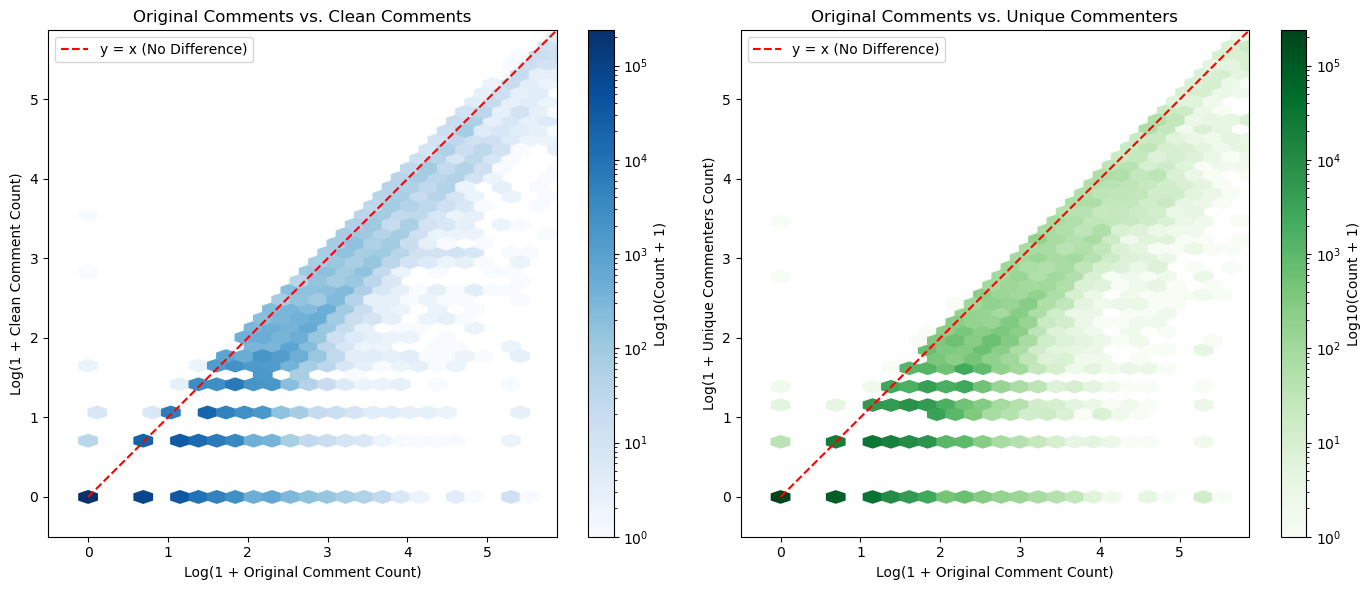

In [2]:
# We will use log(1+x) since the data is highly skewed (max 100k comments)
df['log1p_orig'] = np.log1p(df['orig_comments'])
df['log1p_clean'] = np.log1p(df['clean_comments'])
df['log1p_unique'] = np.log1p(df['unique_commenters'])

# Cap at 99.9th percentile for plotting (prevent extreme outliers from blowing out the axis)
max_val_orig = df['log1p_orig'].quantile(0.999)
max_val_clean = df['log1p_clean'].quantile(0.999)
max_val_plot = max(max_val_orig, max_val_clean) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Orig vs Clean
hb1 = axes[0].hexbin(df['log1p_orig'], df['log1p_clean'], gridsize=50, cmap='Blues', mincnt=1, bins='log')
axes[0].plot([0, max_val_plot], [0, max_val_plot], 'r--', label='y = x (No Difference)')
axes[0].set_title("Original Comments vs. Clean Comments")
axes[0].set_xlabel("Log(1 + Original Comment Count)")
axes[0].set_ylabel("Log(1 + Clean Comment Count)")
axes[0].set_xlim(-0.5, max_val_plot)
axes[0].set_ylim(-0.5, max_val_plot)
axes[0].legend()
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label('Log10(Count + 1)')

# Plot 2: Orig vs Unique
hb2 = axes[1].hexbin(df['log1p_orig'], df['log1p_unique'], gridsize=50, cmap='Greens', mincnt=1, bins='log')
axes[1].plot([0, max_val_plot], [0, max_val_plot], 'r--', label='y = x (No Difference)')
axes[1].set_title("Original Comments vs. Unique Commenters")
axes[1].set_xlabel("Log(1 + Original Comment Count)")
axes[1].set_ylabel("Log(1 + Unique Commenters Count)")
axes[1].set_xlim(-0.5, max_val_plot)
axes[1].set_ylim(-0.5, max_val_plot)
axes[1].legend()
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label('Log10(Count + 1)')

plt.tight_layout()
plt.show()